# CELL 1 — Install Libraries

In [1]:
!pip install stable-baselines3 gymnasium matplotlib numpy

# CELL 2 — Imports

In [2]:
import gymnasium as gym
from gymnasium import spaces

import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback

In [3]:
import random

np.random.seed(42)
random.seed(42)

# CELL 3 — Secure 6G Environment

In [4]:
class Secure6GEnv(gym.Env):

    def __init__(self):

        super(Secure6GEnv, self).__init__()

        # Actions
        # 0 = increase power
        # 1 = decrease power
        # 2 = beam left
        # 3 = beam right
        # 4 = inject artificial noise

        self.action_space = spaces.Discrete(5)

        # States:
        # [signal_strength, jammer_power, noise_level, eve_distance]

        self.observation_space = spaces.Box(
            low=0,
            high=1,
            shape=(4,),
            dtype=np.float32
        )

        self.state = np.random.rand(4)

        self.secrecy_rate = 0

    def reset(self, seed=None, options=None):

        self.state = np.random.rand(4)

        return self.state, {}

    def step(self, action):

        signal_strength, jammer_power, noise_level, eve_distance = self.state

        # Jammer effect
        signal_strength -= jammer_power * 0.05

        # Actions
        if action == 0:
            signal_strength += 0.1

        elif action == 1:
            signal_strength -= 0.05

        elif action == 2:
            signal_strength += 0.05

        elif action == 3:
            signal_strength += 0.05

        elif action == 4:
            eve_distance += 0.1

        # Random environment changes
        noise_level += np.random.uniform(-0.02, 0.02)
        jammer_power += np.random.uniform(-0.03, 0.03)

        # Keep values between 0 and 1
        signal_strength = np.clip(signal_strength, 0, 1)
        jammer_power = np.clip(jammer_power, 0, 1)
        noise_level = np.clip(noise_level, 0, 1)
        eve_distance = np.clip(eve_distance, 0, 1)

        # Secrecy rate
        secrecy_rate = signal_strength - (1 - eve_distance)

        self.secrecy_rate = secrecy_rate

        # Reward
        reward = (
            secrecy_rate * 5
            - jammer_power
            - noise_level * 0.5
        )

        # Update state
        self.state = np.array([
            signal_strength,
            jammer_power,
            noise_level,
            eve_distance
        ], dtype=np.float32)

        terminated = False
        truncated = False

        return self.state, reward, terminated, truncated, {}

    def render(self):

        signal_strength, jammer_power, noise_level, eve_distance = self.state

        print("\n===== Secure 6G Environment =====")

        print(f"Signal Strength : {signal_strength:.2f}")
        print(f"Jammer Power    : {jammer_power:.2f}")
        print(f"Noise Level     : {noise_level:.2f}")
        print(f"Eve Distance    : {eve_distance:.2f}")

        print("=================================\n")

# CELL 4 — Reward Callback

In [5]:
reward_history = []

class RewardCallback(BaseCallback):

    def __init__(self):

        super().__init__()

    def _on_step(self):

        reward = self.locals["rewards"][0]

        reward_history.append(reward)

        return True

# CELL 5 — Create Environment + Train DQN

In [6]:
env = Secure6GEnv()

model = DQN(
    "MlpPolicy",
    env,
    verbose=0
)

callback = RewardCallback()

model.learn(
    total_timesteps=5000,
    callback=callback
)

print("Training Finished!")

Training Finished!


# CELL 6 — DQN Reward Curve

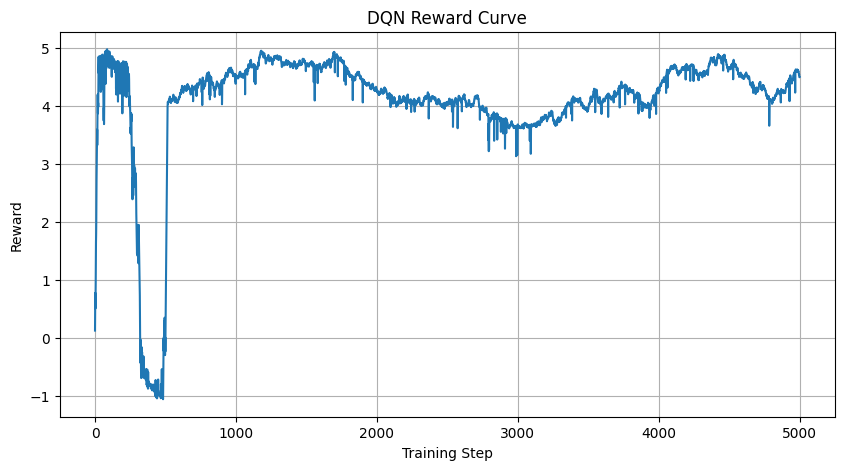

In [7]:
plt.figure(figsize=(10,5))

plt.plot(reward_history)

plt.title("DQN Reward Curve")

plt.xlabel("Training Step")
plt.ylabel("Reward")

plt.grid()

plt.show()

# CELL 7 — Static Baseline

In [8]:
static_rewards = []

env_static = Secure6GEnv()

state, _ = env_static.reset()

for step in range(5000):

    # Static action
    action = env_static.action_space.sample()

    state, reward, terminated, truncated, info = env_static.step(action)

    static_rewards.append(reward)

# CELL 8b — Threshold-Based Heuristic Policy (TBHP)

In [9]:
# Threshold-Based Heuristic Policy (TBHP)
# Rule: if signal < 0.6 -> increase power (0)
#       if eve_distance < 0.7 -> inject noise (4)
#       else -> beam adjustment (2)

tbhp_rewards = []

env_tbhp = Secure6GEnv()

state, _ = env_tbhp.reset()

for step in range(5000):

    signal_strength = state[0]
    eve_distance    = state[3]

    if signal_strength < 0.6:
        action = 0
    elif eve_distance < 0.7:
        action = 4
    else:
        action = 2

    state, reward, terminated, truncated, info = env_tbhp.step(action)

    tbhp_rewards.append(reward)

tbhp_avg_reward = np.mean(tbhp_rewards)

print('Average TBHP Reward:', tbhp_avg_reward)

Average TBHP Reward: 2.8948434600410975


# CELL 8c — DQN vs Static vs TBHP Comparison

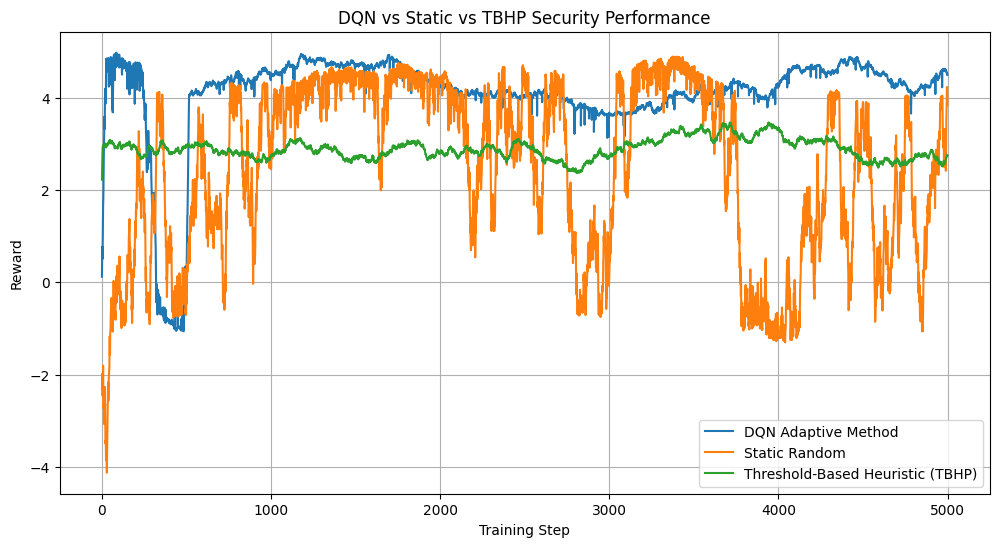

In [10]:
plt.figure(figsize=(12,6))

plt.plot(reward_history, label="DQN Adaptive Method")
plt.plot(static_rewards, label="Static Random")
plt.plot(tbhp_rewards, label="Threshold-Based Heuristic (TBHP)")

plt.title("DQN vs Static vs TBHP Security Performance")

plt.xlabel("Training Step")
plt.ylabel("Reward")

plt.legend()
plt.grid()

plt.savefig("../latex/graph.png", dpi=150, bbox_inches="tight")

plt.show()

# CELL 9 — Average Rewards

In [11]:
dqn_avg_reward    = np.mean(reward_history)

static_avg_reward = np.mean(static_rewards)

tbhp_avg_reward   = np.mean(tbhp_rewards)

print('Average DQN Reward    :', dqn_avg_reward)

print('Average Static Reward :', static_avg_reward)

print('Average TBHP Reward   :', tbhp_avg_reward)

Average DQN Reward    : 4.093141
Average Static Reward : 2.5122046426135314
Average TBHP Reward   : 2.8948434600410975


# CELL 10 — Performance Improvement

In [12]:
improvement_vs_static = (
    (dqn_avg_reward - static_avg_reward)
    / abs(static_avg_reward)
) * 100

improvement_vs_tbhp = (
    (dqn_avg_reward - tbhp_avg_reward)
    / abs(tbhp_avg_reward)
) * 100

print(f'DQN vs Static Improvement: {improvement_vs_static:.2f}%')

print(f'DQN vs TBHP Improvement  : {improvement_vs_tbhp:.2f}%')

DQN vs Static Improvement: 62.93%
DQN vs TBHP Improvement  : 41.39%


# CELL 11 — Secrecy Rate Tracking

In [13]:
secrecy_history = []

obs, _ = env.reset()

for step in range(1000):

    action, _ = model.predict(obs)

    obs, reward, terminated, truncated, info = env.step(action)

    secrecy_history.append(env.secrecy_rate)

# CELL 12 — Secrecy Rate Graph

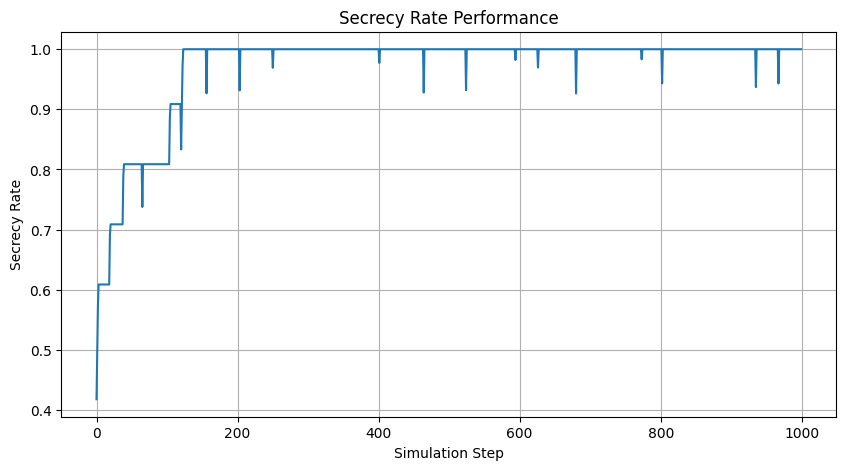

In [14]:
plt.figure(figsize=(10,5))

plt.plot(secrecy_history)

plt.title("Secrecy Rate Performance")

plt.xlabel("Simulation Step")
plt.ylabel("Secrecy Rate")

plt.grid()

plt.show()

# CELL 13 — Static Network Visualization

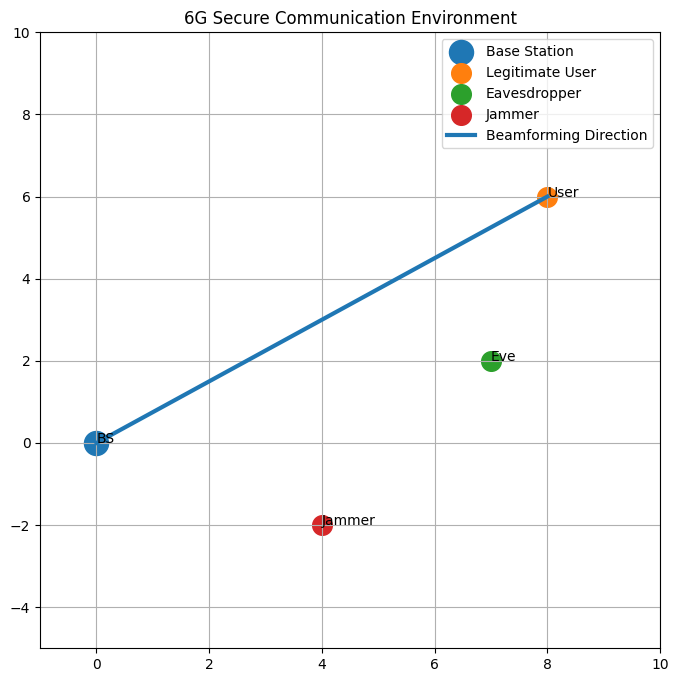

In [15]:
# Positions

bs_x, bs_y = 0, 0

user_x, user_y = 8, 6

eve_x, eve_y = 7, 2

jammer_x, jammer_y = 4, -2

plt.figure(figsize=(8,8))

# Base Station
plt.scatter(bs_x, bs_y, s=300, label="Base Station")

# User
plt.scatter(user_x, user_y, s=200, label="Legitimate User")

# Eve
plt.scatter(eve_x, eve_y, s=200, label="Eavesdropper")

# Jammer
plt.scatter(jammer_x, jammer_y, s=200, label="Jammer")

# Beamforming line
plt.plot(
    [bs_x, user_x],
    [bs_y, user_y],
    linewidth=3,
    label="Beamforming Direction"
)

# Labels
plt.text(bs_x, bs_y, "BS")
plt.text(user_x, user_y, "User")
plt.text(eve_x, eve_y, "Eve")
plt.text(jammer_x, jammer_y, "Jammer")

# Settings
plt.xlim(-1, 10)
plt.ylim(-5, 10)

plt.title("6G Secure Communication Environment")

plt.legend()
plt.grid()

plt.show()

# CELL 14 — Dynamic Visualization

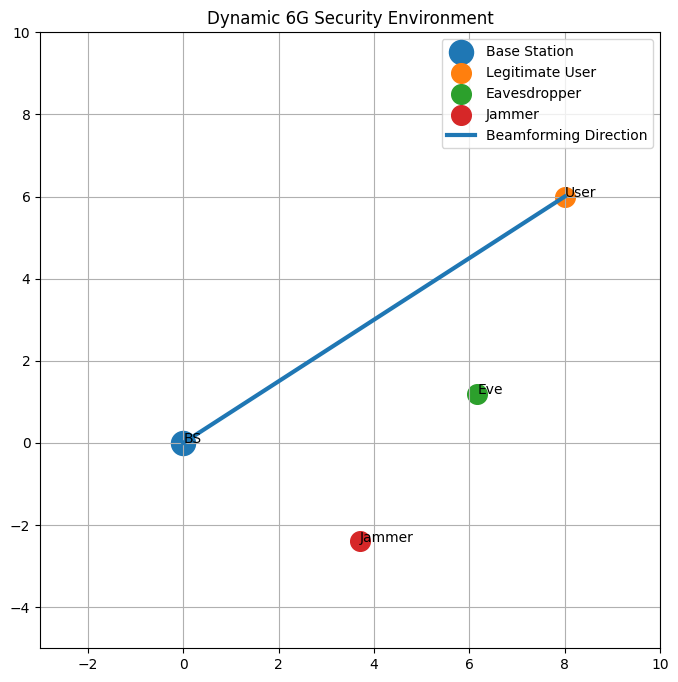

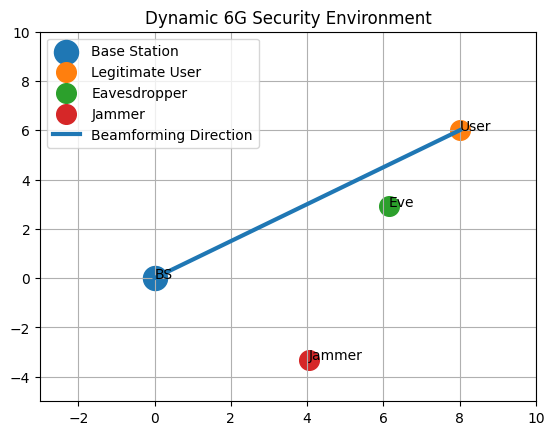

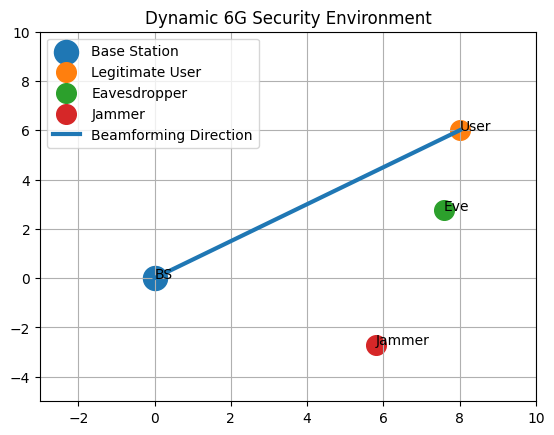

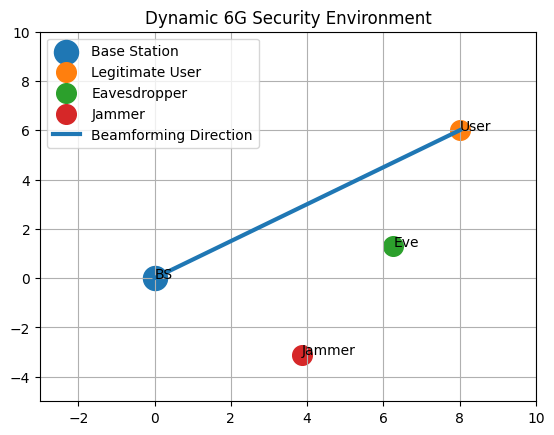

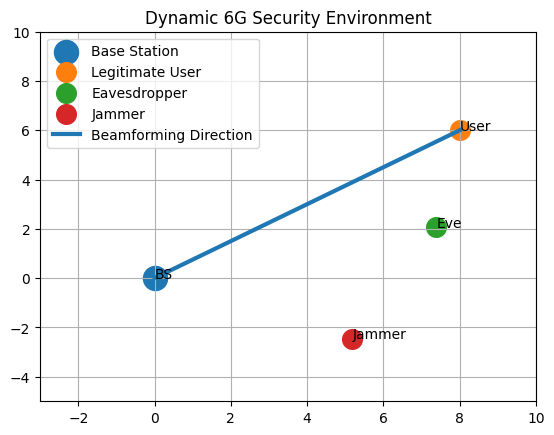

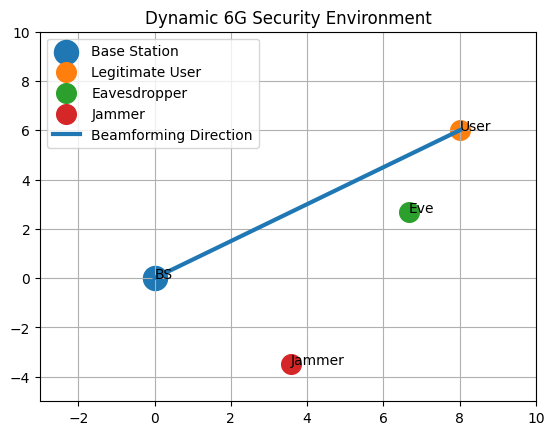

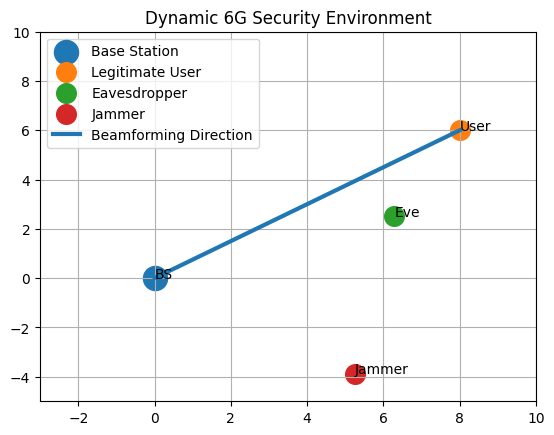

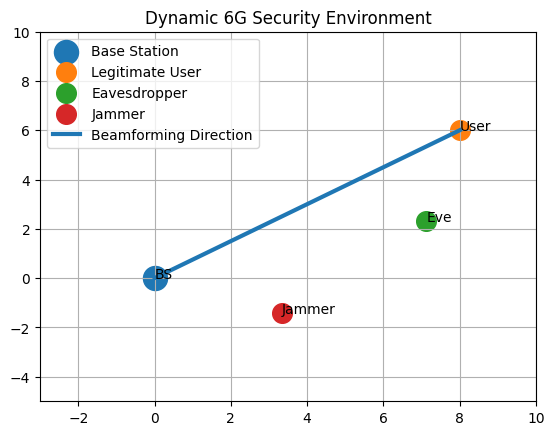

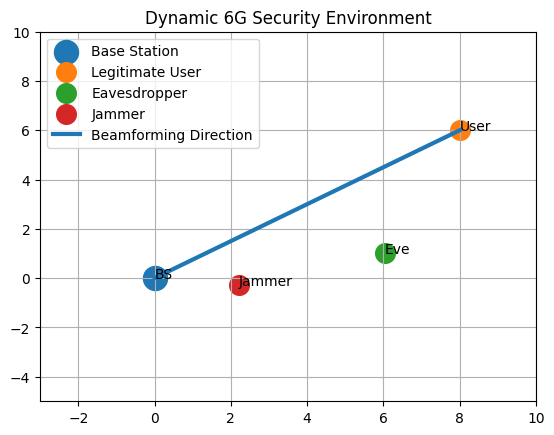

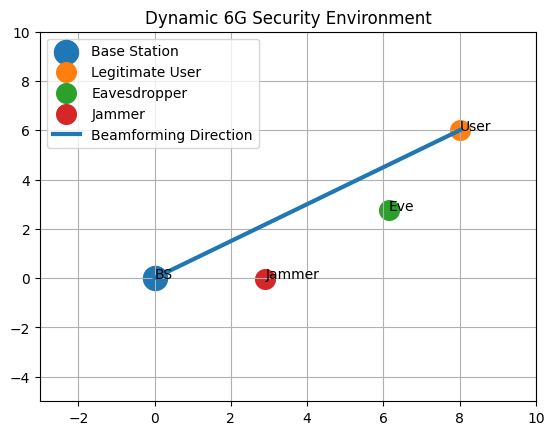

In [16]:
# Base Station
bs_x, bs_y = 0, 0

# User
user_x, user_y = 8, 6

plt.figure(figsize=(8,8))

for step in range(10):

    plt.clf()

    # Dynamic jammer movement
    jammer_x = 4 + np.random.uniform(-2, 2)
    jammer_y = -2 + np.random.uniform(-2, 2)

    # Dynamic Eve movement
    eve_x = 7 + np.random.uniform(-1, 1)
    eve_y = 2 + np.random.uniform(-1, 1)

    # Draw nodes
    plt.scatter(bs_x, bs_y, s=300, label="Base Station")

    plt.scatter(user_x, user_y, s=200, label="Legitimate User")

    plt.scatter(eve_x, eve_y, s=200, label="Eavesdropper")

    plt.scatter(jammer_x, jammer_y, s=200, label="Jammer")

    # Beamforming line
    plt.plot(
        [bs_x, user_x],
        [bs_y, user_y],
        linewidth=3,
        label="Beamforming Direction"
    )

    # Labels
    plt.text(bs_x, bs_y, "BS")

    plt.text(user_x, user_y, "User")

    plt.text(eve_x, eve_y, "Eve")

    plt.text(jammer_x, jammer_y, "Jammer")

    # Limits
    plt.xlim(-3, 10)
    plt.ylim(-5, 10)

    plt.title("Dynamic 6G Security Environment")

    plt.grid()
    plt.legend()

    plt.pause(0.5)

plt.show()